## Dependencies

In [1]:
import pandas as pd 
from CreditScoringToolkit import frequency_table
from CreditScoringToolkit import DiscreteNormalizer
from CreditScoringToolkit import WoeEncoder
from CreditScoringToolkit import WoeContinuousFeatureSelector
from CreditScoringToolkit import WoeDiscreteFeatureSelector
from CreditScoringToolkit import CreditScoring
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.preprocessing._discretization")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\GROUP\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\GROUP\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\GROUP\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\GROUP\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\GROUP\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\GROUP\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## Reading example data

In [2]:
#  Read example data for train and validation (loan applications)
train = pd.read_csv('example_data/train.csv')
valid = pd.read_csv('example_data/valid.csv')   

## Defining feature type

In [3]:
#  Assign features lists by type, file contains "C_" prefix for continuous, and "D_" for discrete.
vard = [v for v in train.columns if v[:2]=='D_']
varc = [v for v in train.columns if v[:2]=='C_']

## Normalize Discrete Features

In [4]:
#  In this example, we aggregate categories with less than 10% of relative frequency
#  into a new category called 'SMALL CATEGORIES', if new created category don't reach
#  given relative frequency threshold (10%) then the most frequent category is imputed.
#  All missing values are treatead as the separate category MISSING

dn = DiscreteNormalizer(normalization_threshold=0.1,default_category='SMALL CATEGORIES')
dn.fit(train[vard])
Xt = dn.transform(train[vard])
frequency_table(Xt,vard)

**** Frequency Table for D_OCCUPATION_TYPE ****

                   Abs. Freq.  Rel. Freq.  Cum. Abs. Freq.  Cum. Rel. Freq.
D_OCCUPATION_TYPE                                                          
Laborers                  166       0.166              166            0.166
MISSING                   325       0.325              491            0.491
SMALL CATEGORIES          395       0.395              886            0.886
Sales staff               114       0.114             1000            1.000




**** Frequency Table for D_NAME_CONTRACT_TYPE ****

                      Abs. Freq.  Rel. Freq.  Cum. Abs. Freq.  Cum. Rel. Freq.
D_NAME_CONTRACT_TYPE                                                          
Cash loans                   897       0.897              897            0.897
Revolving loans              103       0.103             1000            1.000




**** Frequency Table for D_CODE_GENDER ****

               Abs. Freq.  Rel. Freq.  Cum. Abs. Freq.  Cum. Rel. Freq.
D_

### Check if Normalization process didn't produce unary features

In [5]:
unary = [v for v in vard if Xt[v].nunique()==1]
unary

[]

## WoE Based Best Feature Selection

In [6]:
#   Now we proceed with feature selection, we have special classes for each type of feature (discrete,continuous)
#   Discrete feature selector uses the given iv_threshold to select the best features only.
#   For continuous feature selector, a variety of methods are available for selecting the best features , namely:
#    -uniform: only uses equal-width discretized bins, selects number of bins with best IV value.  
#    -quantile: only uses equal-frequency discretized bins, selects number of bins with best IV value 
#    -kmeans: only uses discretized bins created by a K-Means clustering, selects number of bins with best IV value 
#    -gaussian: only uses discretized bins created by a Gaussian Mixture, selects number of bins with best IV value
#    -dcc: stands for Discrete Competitive Combination, creates segments for all individual methods and then 
#          selects the best method and its corresponding best number of bins for each feature.
#    -dec: stands for Discrete Exhaustive Combination, creates segments for all individual methods and then 
#          selects the best number of bins for each feature including every feasible method.
#
#   One can configure IV threshold, minimun/maximum number of discretization bins, whether or not to keep only
#   strictly monotonic segments and the number of pooling threads used in order to speed computations. 


Xt = pd.concat([Xt,train[varc]],axis=1) #Merge continuous features matrix with the normalized discrete predictors Matrix

wcf = WoeContinuousFeatureSelector()
wdf = WoeDiscreteFeatureSelector()

#  Perform feature selection
wcf.fit(Xt[varc],train['TARGET'],
        max_bins=6,
        strictly_monotonic=True,
        iv_threshold=0.05,
        method='dcc',
        n_threads=20)

wdf.fit(Xt[vard],train['TARGET'],iv_threshold=0.1)

#  Create new matrix with discrete and discretized best features 
Xt = pd.concat([wdf.transform(Xt[vard]),wcf.transform(Xt[varc])],axis=1)

features = list(Xt.columns)

#  Print selection results
print("Best continuous features: ", wcf.selected_features)
print("Best discrete features: ",wdf.selected_features)
print("Best Features selected: ",features)

Best continuous features:  [{'feature': 'disc_C_AMT_GOODS_PRICE_2_kmeans', 'iv': 0.054272636178136976, 'relevant': True, 'root_feature': 'C_AMT_GOODS_PRICE', 'nbins': '2', 'method': 'kmeans', 'selected': True}, {'feature': 'disc_C_OWN_CAR_AGE_3_kmeans', 'iv': 0.13493592841524896, 'relevant': True, 'root_feature': 'C_OWN_CAR_AGE', 'nbins': '3', 'method': 'kmeans', 'selected': True}, {'feature': 'disc_C_TOTALAREA_MODE_3_quantile', 'iv': 0.1259702243075047, 'relevant': True, 'root_feature': 'C_TOTALAREA_MODE', 'nbins': '3', 'method': 'quantile', 'selected': True}]
Best discrete features:  {'D_CODE_GENDER': 0.10698023203218116}
Best Features selected:  ['D_CODE_GENDER', 'disc_C_AMT_GOODS_PRICE_2_kmeans', 'disc_C_OWN_CAR_AGE_3_kmeans', 'disc_C_TOTALAREA_MODE_3_quantile']


## WoE Transformation 

In [7]:
#  Weight of Evidence Transformation
we = WoeEncoder()
we.fit(Xt[features],train['TARGET'])
Xwt = we.transform(Xt[features])
Xwt.head()

d:\charlesDevelopment\clone\python\woe_credit_scoring\woe_credit_scoring\CreditScoringToolkit.py:550: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aux[feature] = aux[feature].replace(woe_map)


,D_CODE_GENDER,disc_C_AMT_GOODS_PRICE_2_kmeans,disc_C_OWN_CAR_AGE_3_kmeans,disc_C_TOTALAREA_MODE_3_quantile
0,-0.397247,-0.066175,-0.099648,-0.230676
1,0.271721,-0.066175,-0.099648,-0.035932
2,0.271721,-0.066175,-0.099648,-0.126945
3,0.271721,-0.066175,-0.099648,-0.126945
4,0.271721,-0.066175,-0.099648,-0.230676


## Logistic Regression Parameter Learning

In [8]:
lr = LogisticRegression()
lr.fit(Xwt,train['TARGET'])
print("AUC for training: ",roc_auc_score(y_score=lr.predict_proba(Xwt)[:,1],y_true=train['TARGET']))

AUC for training:  0.6688320314575694


## Scoring

In [9]:
#  In order to perform the scoring transformation, we need the WoE encoded data, 
#  the WoeEncoder fitted object and the logistic regression fitter object 
#  to produce a nice formatted scorecard
cs = CreditScoring()
cs.fit(Xwt,we,lr)
cs.scorecard

points
feature                          attribute                 
D_CODE_GENDER                    F                       90
                                 M                       71
disc_C_AMT_GOODS_PRICE_2_kmeans  (-inf, 730735.795]      81
                                 (730735.795, inf]       89
                                 MISSING                 35
disc_C_OWN_CAR_AGE_3_kmeans      (-inf, 12.582]         102
                                 (12.582, 41.679]        70
                                 (41.679, inf]           68
                                 MISSING                 80
disc_C_TOTALAREA_MODE_3_quantile (-inf, 0.053]           77
                                 (0.053, 0.111]          81
                                 (0.111, inf]           105
                                 MISSING                 79

## Validation

### Model Generalization

In [10]:
#  Applying all transformations to the validation data is now easy and straightforward
#  we can compute AUC to check model overfitting
Xv = pd.concat([wdf.transform(dn.transform(valid[vard])),wcf.transform(valid[varc])],axis=1)
Xwv = we.transform(Xv)
print("AUC for validation: ",roc_auc_score(y_score=lr.predict_proba(Xwv)[:,1],y_true=valid['TARGET']))

AUC for validation:  0.6721863542164833


d:\charlesDevelopment\clone\python\woe_credit_scoring\woe_credit_scoring\CreditScoringToolkit.py:550: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aux[feature] = aux[feature].replace(woe_map)


### Scoring Distributions

d:\charlesDevelopment\clone\python\woe_credit_scoring\woe_credit_scoring\CreditScoringToolkit.py:920: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aux[feature] = aux[feature].replace(points_map)
d:\charlesDevelopment\clone\python\woe_credit_scoring\woe_credit_scoring\CreditScoringToolkit.py:920: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aux[feature] = aux[feature].replace(points_map)


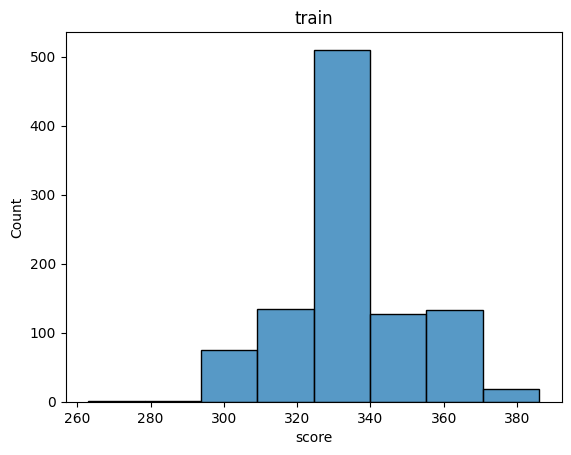

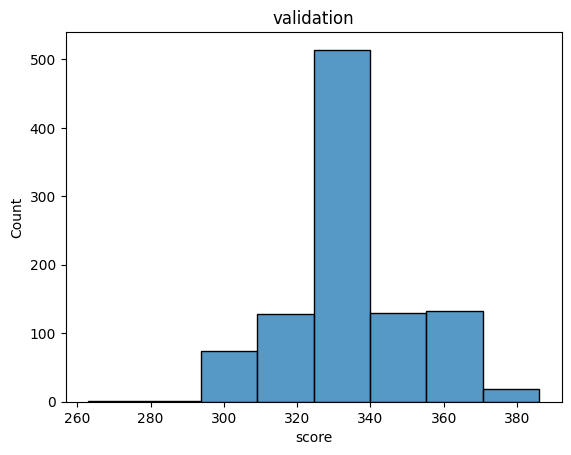

In [11]:
#  We can check the score transformation distributions for training and validation
score = pd.concat([pd.concat([cs.transform(we.inverse_transform(Xwv))[['score']].assign(sample='validation'),valid['TARGET']],axis=1),
pd.concat([cs.transform(we.inverse_transform(Xwt))[['score']].assign(sample='train'),train['TARGET']],axis=1)
                  ],ignore_index=True)

for s,d in score.groupby('sample'):
    plt.figure()
    plt.title(s)
    sns.histplot(d['score'],legend=True,fill=True,bins=8)

### Event rates

<Figure size 640x480 with 0 Axes>

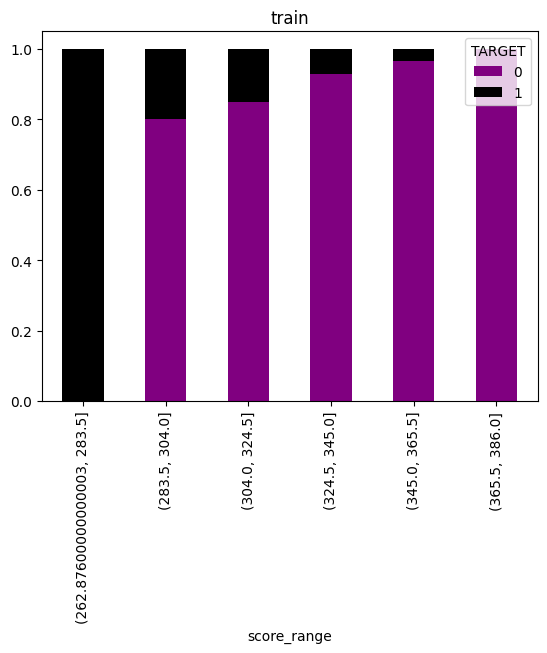

<Figure size 640x480 with 0 Axes>

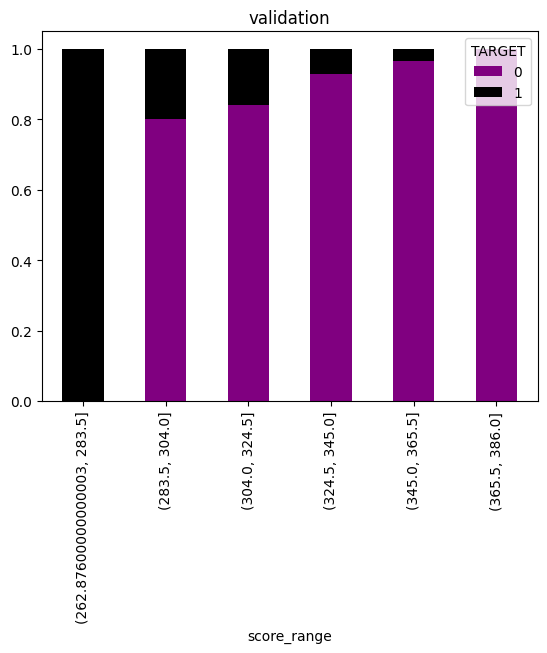

In [12]:
#   We can observe that, the greater the score, the lower the probability of being a 
#   bad customer (label=1) for both samples. Now all complexity is absorbed   
score['score_range'] = pd.cut(score['score'],bins=6,include_lowest=True).astype(str)
for s,d in score.groupby('sample'):
    aux = d.pivot_table(index='TARGET',
                        columns='score_range',
                        values='score',
                        aggfunc='count',
                        fill_value=0)
    aux/=aux.sum()
    aux = aux.T
    plt.figure()
    ax = aux.plot(kind='bar',stacked=True,color=['purple','black'])
    plt.title(s)

d:\charlesDevelopment\clone\python\woe_credit_scoring\woe_credit_scoring\CreditScoringToolkit.py:550: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aux[feature] = aux[feature].replace(woe_map)
d:\charlesDevelopment\clone\python\woe_credit_scoring\woe_credit_scoring\CreditScoringToolkit.py:550: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aux[feature] = aux[feature].replace(woe_map)
2025-05-16 09:50:17,422 - CreditScoringToolkit - WARNING - Overfitting detected, review your hyperparameters. train_auc: 0.7044087375342247, valid_auc

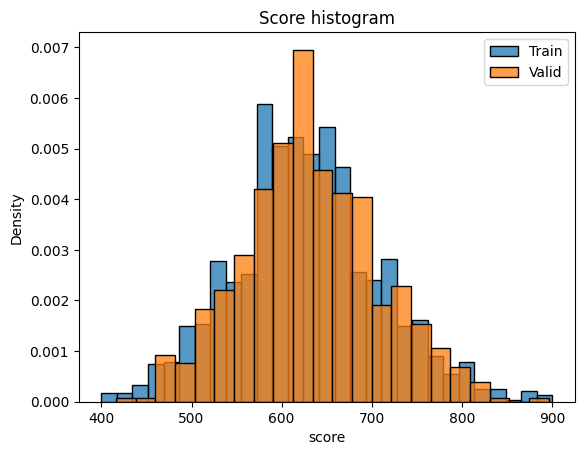

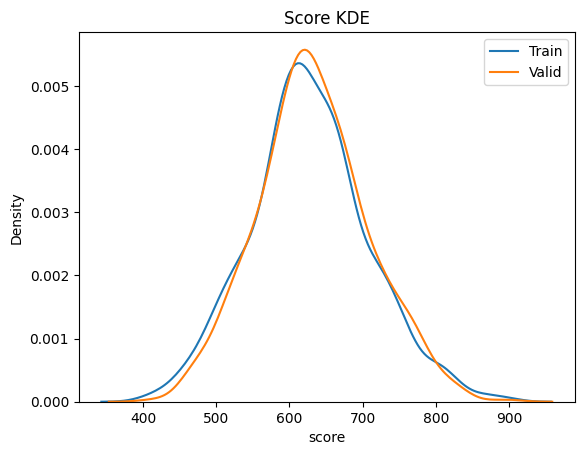

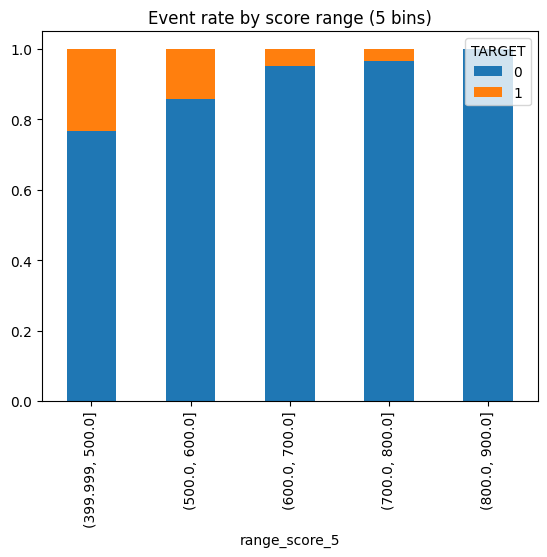

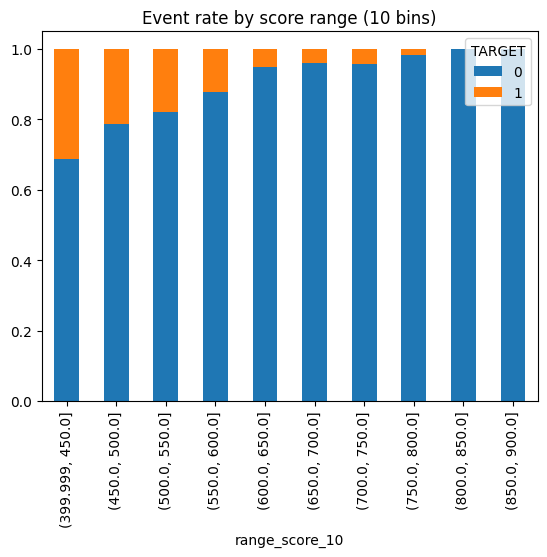

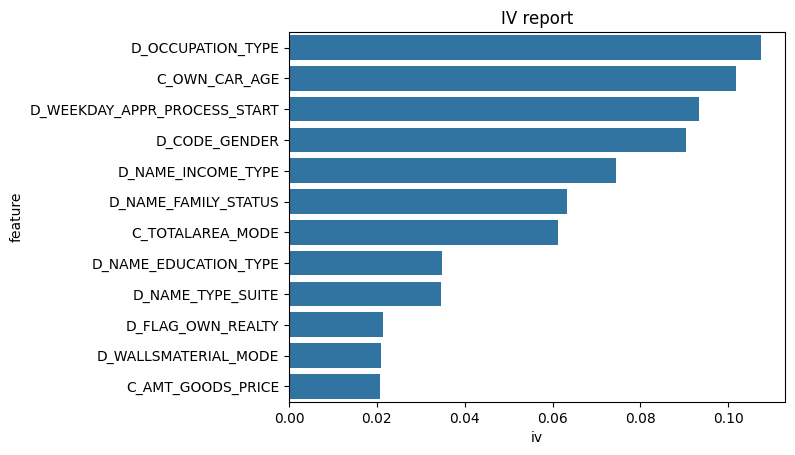

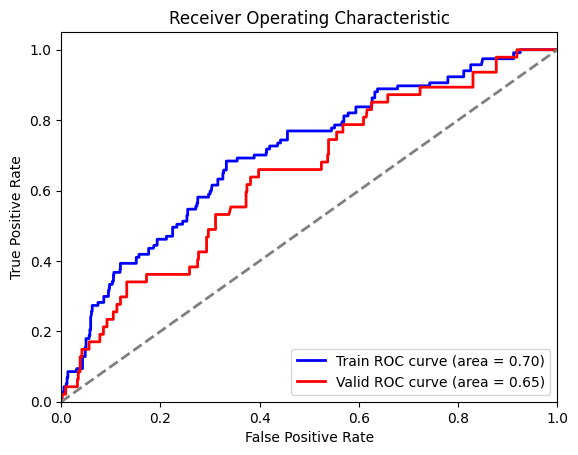

In [13]:
# If you prefer, use AutoCreditScoring class to perform all the steps in a single call with additional features
# like outlier detection and treatment, feature selection, reporting and more.
from CreditScoringToolkit import AutoCreditScoring

data = pd.concat([train,valid],axis=0)
kwargs = {'iv_feature_threshold':0.02,'max_discretization_bins':6,'strictly_monotonic':True}
acs = AutoCreditScoring(data,'TARGET',varc,vard)
acs.fit(**kwargs)

# You can also save the reports to a folder in PNG format
acs.save_reports('reports')

In [14]:
import joblib

In [15]:
# Save the trained model for later use in the web app
joblib.dump(acs, 'credit_scoring_model.joblib')
print("Model saved as credit_scoring_model.joblib")

Model saved as credit_scoring_model.joblib
